# Lab 3 — Descriptive Statistics Assignment: Gym Membership Dataset

**School of Computer Science and Engineering (SOCSE) — RV University**

**Name:** _____Chetan Kumar__________________________  **Roll No.:** ______1RUA25CSE0137_________  **Section:** ___G____

---

## Instructions

- This is a follow-up to Lab 3 (descriptive statistics on the student survey dataset). The same
  concepts — central tendency, dispersion, distribution shape, and visualization — are applied here
  to a **new dataset** describing gym members, so you can practice choosing the right
  statistic rather than remembering the answer from Lab 3.
-
- Every question below has an empty code cell (marked `# TODO`) for your solution, and most also   have a markdown cell marked **Your answer:** for a short written interpretation. Write your
  interpretation in your own words — a correct number with no explanation will not receive full  marks for questions that ask you to interpret.
- Run your notebook **top to bottom** (Kernel → Restart & Run All) before submitting, and make sure
  it completes with no errors.
-

### Learning objectives
By the end of this assignment you should be able to: compute and correctly choose between mean,
median, and mode; compute and interpret variance, standard deviation, and IQR; use skewness and
kurtosis to identify non-normal distributions; and build/interpret histograms, box plots, and scatter plots to support (or challenge) what the summary statistics suggest.

In [3]:
# --- Core libraries used throughout the notebook (provided — no changes needed) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 3)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 7


## Part 1 — The Dataset (provided, do not modify)

This dataset simulates **150 gym members**, with the same design idea as Lab 3: each numeric
feature is deliberately shaped differently, so no single statistic works well for all of them.

| Feature | Real-world meaning | Intended shape |
|---|---|---|
| `workout_duration_minutes` | Average length of a workout session | *(shape not disclosed — see Q7/Q8)* |
| `monthly_membership_fee_inr` | Monthly membership fee paid (₹) | *(shape not disclosed — see Q7/Q8)* |
| `attendance_percentage` | % of scheduled sessions actually attended | *(shape not disclosed — see Q7/Q8)* |
| `weekly_visit_count` | Number of gym visits per week | *(shape not disclosed — see Q7/Q8)* |
| `preferred_workout` | Favorite workout category | categorical |

Unlike Lab 3, the shapes are **not labeled** for you this time — figuring out which feature is
approximately normal, right-skewed, left-skewed, or bimodal (and *proving it* with statistics and
plots) is part of the assignment.

In [4]:
df=pd.read_csv("gym_members_synthetic.csv")
df.head(8)

,member_id,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count,preferred_workout
0,M001,69.7,1690.0,71.7,1.3,Cardio
1,M002,81.0,2450.0,86.2,2.2,Weights
2,M003,62.6,2190.0,89.0,5.1,CrossFit
3,M004,65.7,3170.0,79.6,5.4,Cardio
4,M005,49.3,1050.0,80.7,1.5,Weights
5,M006,39.1,1180.0,88.0,5.0,Weights
6,M007,52.3,800.0,81.3,2.1,Weights
7,M008,73.0,2630.0,82.3,5.5,Yoga


In [1]:
FEATURES = [
    "workout_duration_minutes",
    "monthly_membership_fee_inr",
    "attendance_percentage",
    "weekly_visit_count"
]

### Q1 (2 marks) — Initial exploration

In the code cell below: display the shape of `df`, the data type of each column (`.dtypes`), the
summary statistics of the numeric columns (`.describe()`), and check whether any values are
missing (`.isna().sum()`).

In [5]:
# TODO: Q1 — shape, dtypes, describe(), and missing-value check
print("Shape of dataset:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
display(df.describe())

print("\nMissing Values:")
print(df.isna().sum())

Shape of dataset: (150, 6)

Data Types:
member_id                      object
workout_duration_minutes      float64
monthly_membership_fee_inr    float64
attendance_percentage         float64
weekly_visit_count            float64
preferred_workout              object
dtype: object

Summary Statistics:


,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count
count,150.000,150.000,150.000,150.000
mean,54.618,2283.067,84.210,3.337
std,11.397,984.837,5.874,1.886
min,27.800,800.000,66.200,0.300
25%,48.050,1515.000,80.175,1.800
50%,54.350,2030.000,85.100,2.400
75%,62.875,2825.000,88.775,5.300
max,81.000,6420.000,94.700,7.100



Missing Values:
member_id                     0
workout_duration_minutes      0
monthly_membership_fee_inr    0
attendance_percentage         0
weekly_visit_count            0
preferred_workout             0
dtype: int64


## Part 2 — Measures of Central Tendency

Recall from Lab 3: the **mean** uses every value and is efficient but outlier-sensitive; the
**median** only depends on the middle position and is robust to outliers; the **mode** is the most
frequent value and is most meaningful for categorical or discrete data.



In the code cell below, compute the **mean, median, and mode** of each of the four numeric features
in `FEATURES`, and separately the **mode** of `preferred_workout`. Present the four numeric results
as a single small table (a DataFrame is fine).

In [7]:
# TODO: Q2 — mean, median, mode for each numeric feature; mode of preferred_workout
results = []

for feature in FEATURES:
    results.append({
        "Feature": feature,
        "Mean": df[feature].mean(),
        "Median": df[feature].median(),
        "Mode": df[feature].mode()[0]
    })

central_tendency = pd.DataFrame(results)

display(central_tendency)

print("Mode of preferred_workout:")
print(df["preferred_workout"].mode().tolist())

,Feature,Mean,Median,Mode
0,workout_duration_minutes,54.618,54.35,57.8
1,monthly_membership_fee_inr,2283.067,2030.00,1440.0
2,attendance_percentage,84.210,85.10,85.1
3,weekly_visit_count,3.337,2.40,2.3


Mode of preferred_workout:
['Cardio', 'Weights']


### Q3  — Written interpretation

Looking at your table from Q2: for which numeric feature(s) do the mean and median differ the most
(in relative, not absolute, terms)? What does that gap suggest about the shape of that feature's
distribution, and in which direction would you expect its tail to stretch? You have not plotted
anything yet — base your answer only on the numbers.

**Your answer:**

_(write here)_

### Q4 (4 marks) — The outlier effect

Suppose one gym member signs up for a **founder's lifetime membership** and pays a one-time fee of
**₹80,000** that month. In the code cell below: make a **copy** of `df` (do not modify the original
`df`), add this one hypothetical value to `monthly_membership_fee_inr` in the copy, and print the
mean and median of that column **before and after** adding it.

Then, in the markdown cell below, explain in 2–3 sentences why the mean and median reacted
differently, referencing what you know about how each statistic is calculated.

In [8]:
# TODO: Q4 — add the ₹80,000 outlier to a COPY of df, compare mean/median before vs. after
# Original values
original_mean = df["monthly_membership_fee_inr"].mean()
original_median = df["monthly_membership_fee_inr"].median()

# Make a copy
df_outlier = df.copy()

# Add hypothetical ₹80,000 membership fee
df_outlier.loc[len(df_outlier), "monthly_membership_fee_inr"] = 80000

# New values
new_mean = df_outlier["monthly_membership_fee_inr"].mean()
new_median = df_outlier["monthly_membership_fee_inr"].median()

comparison = pd.DataFrame({
    "Statistic": ["Mean", "Median"],
    "Before Outlier": [original_mean, original_median],
    "After Outlier": [new_mean, new_median]
})

display(comparison)

,Statistic,Before Outlier,After Outlier
0,Mean,2283.067,2797.748
1,Median,2030.000,2030.000


## Part 3 — Measures of Dispersion

### Q5 (5 marks) — Manual calculation

Without using `.var()`, `.std()`, `np.var()`, or `np.std()`, calculate the **variance** and
**standard deviation** of `workout_duration_minutes` by hand, following the sample-variance formula:

$$
\text{variance} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
\qquad\qquad
\text{standard deviation} = \sqrt{\text{variance}}
$$

Work through it step by step (compute the mean, then the deviations, then the squared deviations,
then the variance, then the standard deviation — printing each intermediate result), and then
verify your manual answer matches `np.var(..., ddof=1)` and `np.std(..., ddof=1)`.

In [9]:
# TODO: Q5 — manual variance & standard deviation for workout_duration_minutes, then verify
x = df["workout_duration_minutes"]

# Step 1: Calculate mean
mean_x = x.sum() / len(x)

# Step 2: Calculate deviations
deviations = x - mean_x

# Step 3: Calculate squared deviations
squared_deviations = deviations ** 2

# Step 4: Calculate sample variance manually
variance_manual = squared_deviations.sum() / (len(x) - 1)

# Step 5: Calculate standard deviation manually
std_manual = np.sqrt(variance_manual)

print("Mean:", mean_x)
print("\nFirst 10 deviations:")
print(deviations.head(10))

print("\nFirst 10 squared deviations:")
print(squared_deviations.head(10))

print("\nSum of squared deviations:", squared_deviations.sum())

print("\nManual Sample Variance:", variance_manual)
print("Manual Sample Standard Deviation:", std_manual)

# Verification
variance_numpy = np.var(x, ddof=1)
std_numpy = np.std(x, ddof=1)

print("\nVerification using NumPy:")
print("NumPy Variance:", variance_numpy)
print("NumPy Standard Deviation:", std_numpy)

print("\nVariance matches:", np.isclose(variance_manual, variance_numpy))
print("Standard deviation matches:", np.isclose(std_manual, std_numpy))

Mean: 54.618

First 10 deviations:
0    15.082
1    26.382
2     7.982
3    11.082
4    -5.318
5   -15.518
6    -2.318
7    18.382
8   -21.918
9    -5.518
Name: workout_duration_minutes, dtype: float64

First 10 squared deviations:
0    227.467
1    696.010
2     63.712
3    122.811
4     28.281
5    240.808
6      5.373
7    337.898
8    480.399
9     30.448
Name: workout_duration_minutes, dtype: float64

Sum of squared deviations: 19354.7814

Manual Sample Variance: 129.89786174496643
Manual Sample Standard Deviation: 11.397274312087362

Verification using NumPy:
NumPy Variance: 129.8978617449665
NumPy Standard Deviation: 11.397274312087363

Variance matches: True
Standard deviation matches: True


### Q6 — IQR and outlier detection

For **each** of the four numeric features: compute Q1, Q3, and the IQR; compute the lower bound
(`Q1 - 1.5*IQR`) and upper bound (`Q3 + 1.5*IQR`); and count how many values fall outside those
bounds (i.e., how many outliers each feature has by this rule).

**Your answer (2–3 sentences):** Which feature has the most outliers by this rule? Suggest one
real-world reason a gym dataset might realistically show that pattern for that feature.

_(write here)_

In [10]:
# TODO: Q6 — Q1, Q3, IQR, bounds, and outlier count for each of the four numeric features
iqr_results = []

for feature in FEATURES:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]
    
    iqr_results.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

iqr_table = pd.DataFrame(iqr_results)

display(iqr_table)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,workout_duration_minutes,48.050,62.875,14.825,25.812,85.113,0
1,monthly_membership_fee_inr,1515.000,2825.000,1310.000,-450.000,4790.000,2
2,attendance_percentage,80.175,88.775,8.600,67.275,101.675,1
3,weekly_visit_count,1.800,5.300,3.500,-3.450,10.550,0


## Part 4 — Measures of Distribution Shape

### Q7 Compute the **skewness** and **excess kurtosis** of each of the four numeric features (use
`scipy.stats.skew` and `scipy.stats.kurtosis(..., fisher=True)`, or the equivalent pandas
`.skew()` / `.kurt()` methods). Present the results as a table.

For each feature, classify it as **right-skewed**, **left-skewed**, or **approximately symmetric**
based on the skewness value, and note whether the kurtosis suggests heavier tails, lighter tails, or
roughly normal tails compared to a normal distribution.

In [11]:
# TODO: Q7 — skewness & excess kurtosis for each numeric feature, plus your classification
shape_results = []

for feature in FEATURES:
    skewness = stats.skew(df[feature])
    kurtosis = stats.kurtosis(df[feature], fisher=True)
    
    # Skewness classification
    if skewness > 0.5:
        skew_class = "Right-skewed"
    elif skewness < -0.5:
        skew_class = "Left-skewed"
    else:
        skew_class = "Approximately symmetric"
    
    # Kurtosis classification
    if kurtosis > 0.5:
        kurt_class = "Heavier tails"
    elif kurtosis < -0.5:
        kurt_class = "Lighter tails"
    else:
        kurt_class = "Roughly normal tails"
    
    shape_results.append({
        "Feature": feature,
        "Skewness": skewness,
        "Skewness Classification": skew_class,
        "Excess Kurtosis": kurtosis,
        "Kurtosis Interpretation": kurt_class
    })

shape_table = pd.DataFrame(shape_results)

display(shape_table)

,Feature,Skewness,Skewness Classification,Excess Kurtosis,Kurtosis Interpretation
0,workout_duration_minutes,0.080,Approximately symmetric,-0.194,Roughly normal tails
1,monthly_membership_fee_inr,1.165,Right-skewed,1.761,Heavier tails
2,attendance_percentage,-0.556,Left-skewed,-0.353,Roughly normal tails
3,weekly_visit_count,0.441,Approximately symmetric,-1.369,Lighter tails


### Q8 — Predict before you plot

Based only on the real-world meaning of each feature (not the numbers you've computed) — which of
the four features do you predict is **bimodal** (i.e., has two distinct groups of members rather
than one central tendency)? Explain your reasoning in 2–3 sentences, thinking about what kinds of
gym members might behave very differently from each other.

**Your answer:**

_(write here — you will check this prediction against a histogram in Q10)_

## Part 5 — Data Visualizations

### Q9  — Histograms

Create a **2×2 grid of histograms** (one per numeric feature) with a KDE (density) curve overlaid
on each. On each subplot, draw a vertical line for the mean and a different-styled vertical line
for the median (with a legend), and give each subplot a clear title.

*Hint: `sns.histplot(..., kde=True, stat="density")` and `ax.axvline(...)` are useful here — see
Lab 3 for a similar example if you get stuck.*

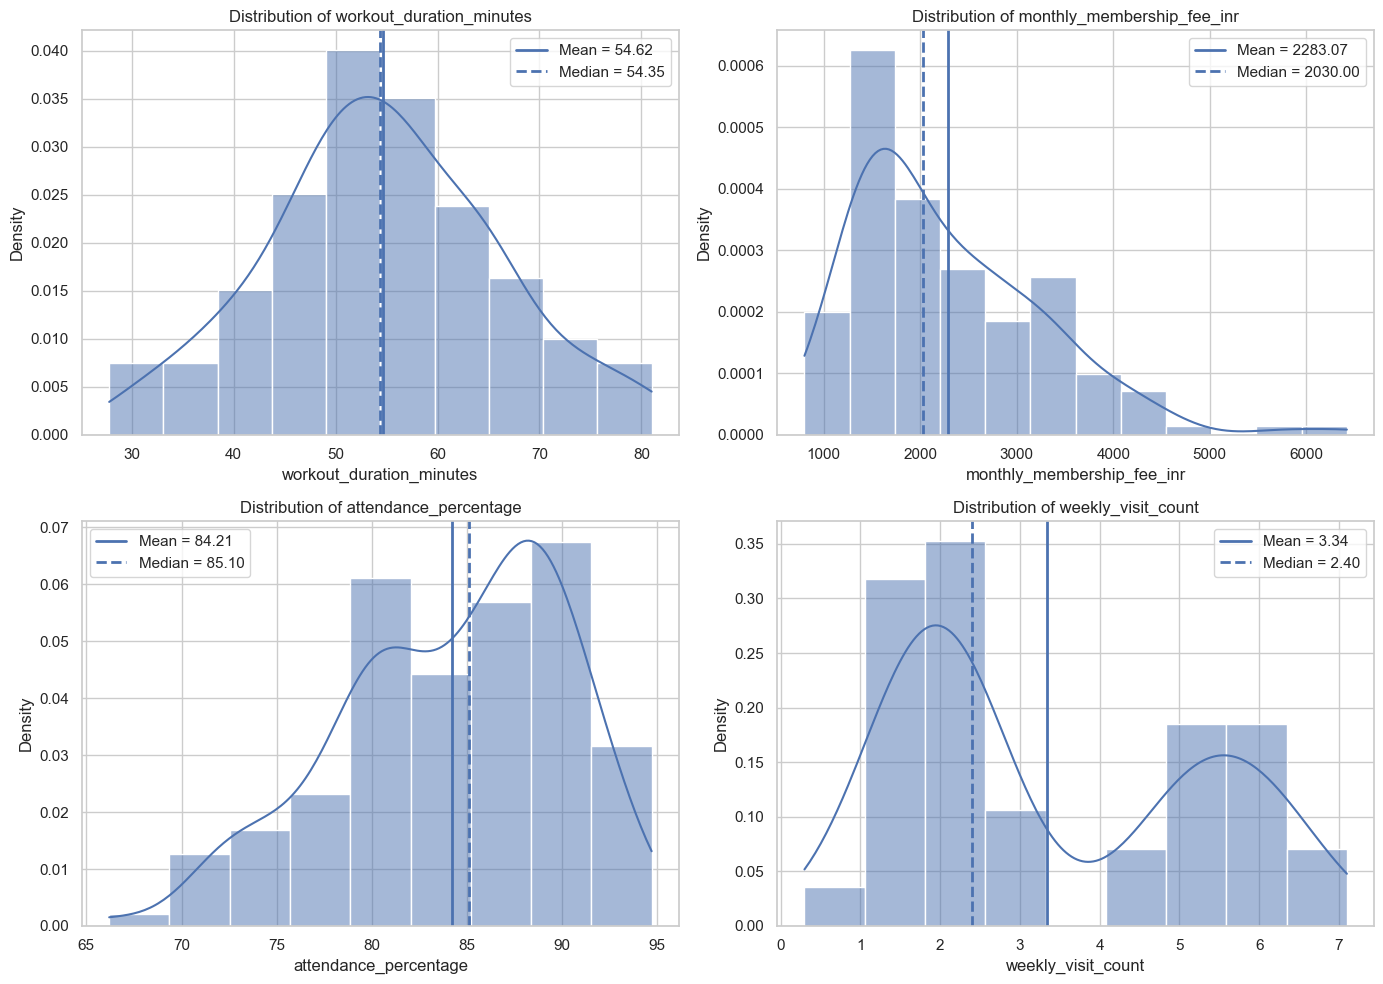

In [12]:
# TODO: Q9 — 2x2 histogram grid with KDE, mean line, and median line per feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flat, FEATURES):
    sns.histplot(
        df[feature],
        kde=True,
        stat="density",
        ax=ax
    )
    
    mean_value = df[feature].mean()
    median_value = df[feature].median()
    
    ax.axvline(
        mean_value,
        linestyle="-",
        linewidth=2,
        label=f"Mean = {mean_value:.2f}"
    )
    
    ax.axvline(
        median_value,
        linestyle="--",
        linewidth=2,
        label=f"Median = {median_value:.2f}"
    )
    
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

### Q10 

Does the histogram for the feature you predicted in Q8 confirm or contradict your prediction?
If your prediction was wrong, which feature actually turned out to be bimodal, and does the mean
computed in Q2 fall in a sensible place on that histogram, or does it fall in an empty "valley"?

**Your answer:**

_(write here)_

### Q11  — Box plots

Standardize (z-score) the four numeric features — `z = (x - mean) / std` — and plot all four as **box plots side by side** on one figure, so their spreads are visually comparable despite being ondifferent original scales (₹, minutes, %, visits). Label the y-axis clearly. Briefly note in the plot title or a code comment which feature(s) show visible outlier points.

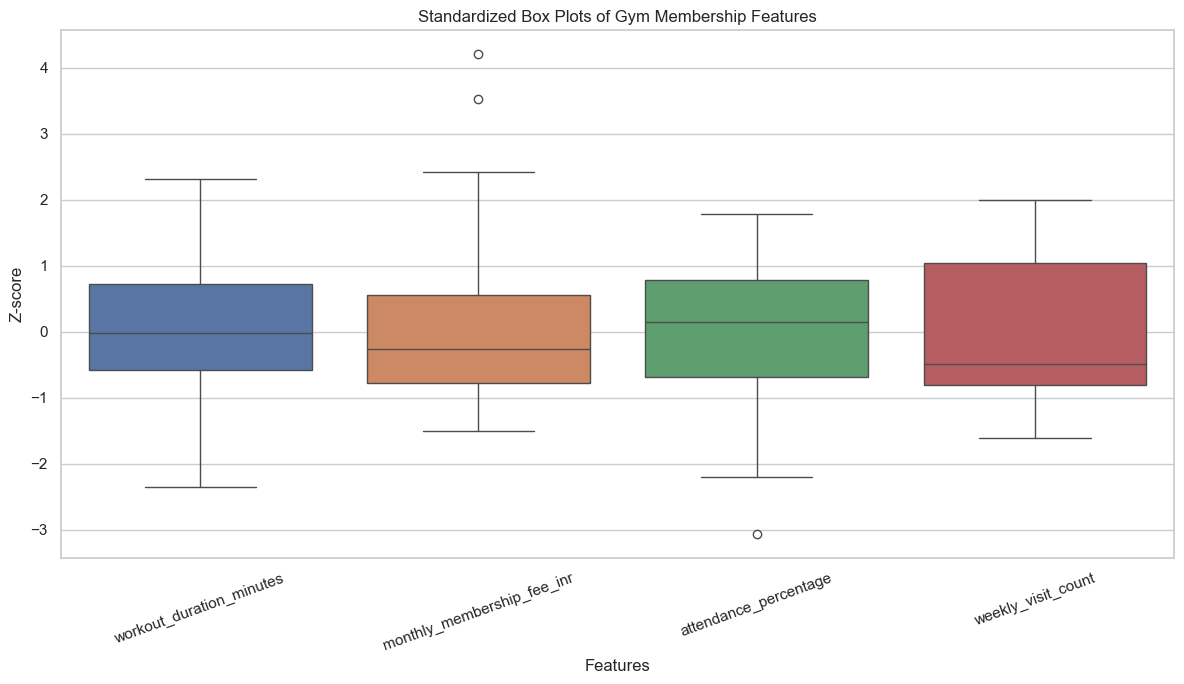

Outlier counts based on 1.5 × IQR rule:
workout_duration_minutes : 0
monthly_membership_fee_inr : 2
attendance_percentage : 1
weekly_visit_count : 0


In [13]:
# TODO: Q11 — standardize all four features and plot them as side-by-side box plots
# Create a copy of the four numeric features
df_z = df[FEATURES].copy()

# Z-score standardization
for feature in FEATURES:
    mean_value = df[feature].mean()
    std_value = df[feature].std()
    
    df_z[feature] = (df[feature] - mean_value) / std_value

# Create box plot
plt.figure(figsize=(12, 7))

sns.boxplot(data=df_z)

plt.title("Standardized Box Plots of Gym Membership Features")
plt.xlabel("Features")
plt.ylabel("Z-score")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Print outlier counts after standardization
print("Outlier counts based on 1.5 × IQR rule:")

for feature in FEATURES:
    q1 = df_z[feature].quantile(0.25)
    q3 = df_z[feature].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    count = ((df_z[feature] < lower) | (df_z[feature] > upper)).sum()
    
    print(feature, ":", count)

### Q12 — Scatter plots

Choose **two pairs** of numeric features: one pair you hypothesize has a real relationship, and one
pair you hypothesize has little to no relationship. For each pair: compute the Pearson correlation
coefficient (`.corr()`), make a scatter plot, and put the correlation value in the plot title.

**Your answer (1–2 sentences per pair):** Did the scatter plots and correlation values support your
hypotheses? If a result surprised you, say so.

_(write here)_

Correlation between attendance_percentage and weekly_visit_count: 0.521
Correlation between workout_duration_minutes and monthly_membership_fee_inr: -0.021


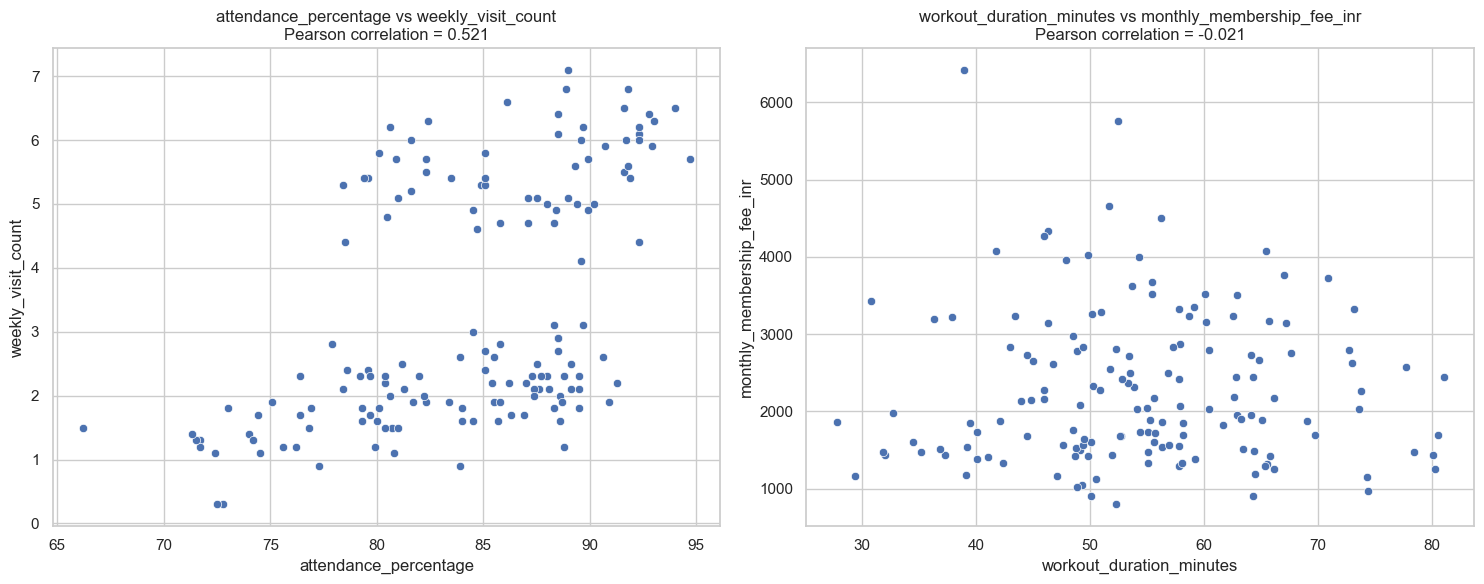

In [14]:
# TODO: Q12 — two scatter plots (one hypothesized relationship, one hypothesized no relationship)
# Pair 1: Hypothesized relationship
x1 = "attendance_percentage"
y1 = "weekly_visit_count"

corr1 = df[x1].corr(df[y1])

# Pair 2: Hypothesized little/no relationship
x2 = "workout_duration_minutes"
y2 = "monthly_membership_fee_inr"

corr2 = df[x2].corr(df[y2])

print(f"Correlation between {x1} and {y1}: {corr1:.3f}")
print(f"Correlation between {x2} and {y2}: {corr2:.3f}")


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# First scatter plot
sns.scatterplot(
    data=df,
    x=x1,
    y=y1,
    ax=axes[0]
)

axes[0].set_title(
    f"{x1} vs {y1}\nPearson correlation = {corr1:.3f}"
)

# Second scatter plot
sns.scatterplot(
    data=df,
    x=x2,
    y=y2,
    ax=axes[1]
)

axes[1].set_title(
    f"{x2} vs {y2}\nPearson correlation = {corr2:.3f}"
)

plt.tight_layout()
plt.show()

## Part 6 — Synthesis

### Q13 

Build **one summary table** with a row per numeric feature and columns for: mean, median, standard
deviation, IQR, skewness, and excess kurtosis (you have already computed all of these in Q2, Q5–Q7
— this question is about assembling them, not recomputing from scratch).

Then write a short paragraph (roughly 100–150 words) that, **for each of the four features**,
recommends which central-tendency measure (mean or median) and which dispersion measure (standard
deviation or IQR) should be reported, and briefly justifies the choice using the specific evidence
in your own table (not general rules quoted from Lab 3).

In [15]:
# TODO: Q13 — assemble the comparative summary table
summary_results = []

for feature in FEATURES:
    summary_results.append({
        "Feature": feature,
        "Mean": df[feature].mean(),
        "Median": df[feature].median(),
        "Standard Deviation": df[feature].std(),
        "IQR": df[feature].quantile(0.75) - df[feature].quantile(0.25),
        "Skewness": stats.skew(df[feature]),
        "Excess Kurtosis": stats.kurtosis(df[feature], fisher=True)
    })

summary_table = pd.DataFrame(summary_results)

display(summary_table)

,Feature,Mean,Median,Standard Deviation,IQR,Skewness,Excess Kurtosis
0,workout_duration_minutes,54.618,54.35,11.397,14.825,0.080,-0.194
1,monthly_membership_fee_inr,2283.067,2030.00,984.837,1310.000,1.165,1.761
2,attendance_percentage,84.210,85.10,5.874,8.600,-0.556,-0.353
3,weekly_visit_count,3.337,2.40,1.886,3.500,0.441,-1.369


---

## Bonus (optional)

Group `df` by `preferred_workout` (`df.groupby("preferred_workout")`) and compare the mean
`attendance_percentage` across the four workout categories. Is attendance noticeably different for
any one category? Give one plausible real-world explanation for what you find (or for why there's
no real difference, if that's what you observe).

preferred_workout
Weights     85.526
Yoga        84.029
Cardio      83.558
CrossFit    82.325
Name: attendance_percentage, dtype: float64

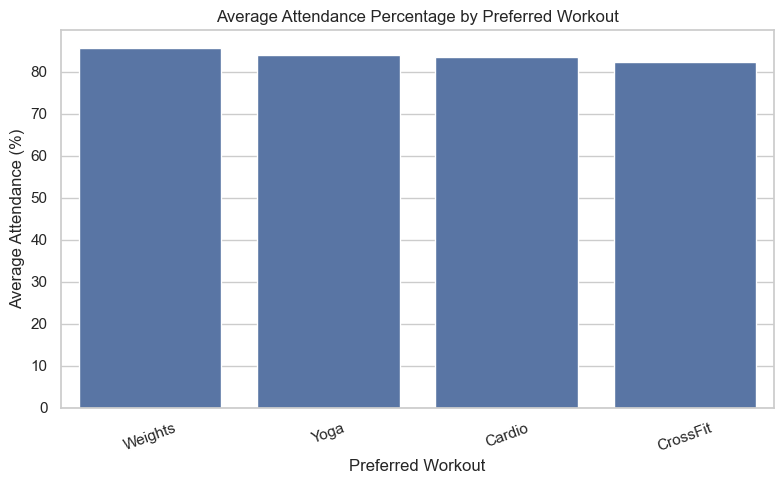

In [16]:
# TODO (bonus): groupby preferred_workout, compare mean attendance_percentage across categories
attendance_by_workout = (
    df.groupby("preferred_workout")["attendance_percentage"]
    .mean()
    .sort_values(ascending=False)
)

display(attendance_by_workout)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=attendance_by_workout.index,
    y=attendance_by_workout.values
)

plt.title("Average Attendance Percentage by Preferred Workout")
plt.xlabel("Preferred Workout")
plt.ylabel("Average Attendance (%)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

---

### Before you submit
- [ ] Ran the notebook top to bottom with no errors (Kernel → Restart & Run All)
- [ ] Every `# TODO` cell has working code, not just comments
- [ ] Every "Your answer" cell has a written response in your own words
- [ ] Did not modify the Part 1 dataset-generation code or the random seed
Done all!